# Final Evaluation


## Install Modal


In [13]:
%pip install modal

Note: you may need to restart the kernel to use updated packages.


## Modal Setup


In [14]:
!python -m modal setup

The web browser should have opened for you to authenticate and get an API 
token.
If it didn't, please copy this URL into your web browser manually:

⠋ Waiting for authentication in the web browser
https://modal.com/token-flow/tf-PhOlQPiPAxNcvu1HdjiwI0

⠋ Waiting for authentication in the web browser
⠋ Waiting for authentication in the web browser

⠋ Waiting for token flow to complete...
⠙ Waiting for token flow to complete...
⠹ Waiting for token flow to complete...
⠸ Waiting for token flow to complete...
⠼ Waiting for token flow to complete...
⠴ Waiting for token flow to complete...
⠦ Waiting for token flow to complete...
⠧ Waiting for token flow to complete...
⠇ Waiting for token flow to complete...
⠏ Waiting for token flow to complete...
⠋ Waiting for token flow to complete...
⠙ Waiting for token flow to complete...
⠸ Waiting for token flow to complete...
⠼ Waiting for token flow to complete...
⠴ Waiting for token flow to complete...
⠦ Waiting for token flow to complete...
⠧ Waiting

## Imports and Modal App Configuration

This cell defines the Modal application and configuration for running multi-model PII detection benchmarks on an H100
GPU.


In [15]:
import modal

APP_NAME: str = "pii-model-comparison"

# Define the Modal App
app = modal.App(name=APP_NAME)

# HuggingFace Hub configuration
# Create the secret first by running in a terminal:
#   modal secret create huggingface HF_TOKEN=hf_your_token_here
HF_SECRET = modal.Secret.from_name("huggingface")

# Create a persistent volume for caching models (optional but recommended)
volume = modal.Volume.from_name("pii-model-cache", create_if_missing=True)
VOLUME_MOUNT_PATH: str = "/model-cache"

print("✓ Modal app configured")
print(f"  App name: {APP_NAME}")
print(f"  Volume mount: {VOLUME_MOUNT_PATH}")

✓ Modal app configured
  App name: pii-model-comparison
  Volume mount: /model-cache


## Docker Image Definition

Builds a custom image with all required dependencies for running multiple PII detection models on an H100 GPU. The image
is cached after the first build for fast subsequent runs.


In [16]:
comparison_image = (
    modal.Image.debian_slim(python_version="3.13")
    # Install system dependencies
    .apt_install("git", "curl", "build-essential")
    # Install PyTorch with CUDA 12.1 support (H100 compatible)
    .pip_install(
        "torch>=2.4.0",
        "torchvision",
        "torchaudio",
        extra_index_url="https://download.pytorch.org/whl/cu121",
    )
    # Install core ML dependencies
    .pip_install(
        # Transformers ecosystem
        "transformers>=4.46.0",
        "peft>=0.14.0",
        "accelerate>=1.0.0",
        "datasets>=3.0.0",
        "huggingface_hub>=0.26.0",
        # Evaluation utilities
        "scikit-learn>=1.5.0",
        "seqeval>=1.2.2",
        "numpy>=1.26.0",
        "tqdm>=4.66.0",
        "pandas>=2.2.0",
        # Sentencepiece for DeBERTa tokenizer
        "sentencepiece>=0.2.0",
        "protobuf>=4.25.0",
        gpu="H100",  # Build with H100 to ensure CUDA compatibility
    )
    # Set environment variables
    .env({
        "HF_HOME": "/root/.cache/huggingface",
        "TRANSFORMERS_CACHE": "/root/.cache/huggingface/hub",
        "TOKENIZERS_PARALLELISM": "false",
    })
)

print("✓ Comparison image defined")
print("  Base: debian_slim (Python 3.13)")
print("  PyTorch: >=2.4.0 (CUDA 12.1)")
print("  Key packages: transformers, peft, datasets, seqeval, scikit-learn")

✓ Comparison image defined
  Base: debian_slim (Python 3.13)
  PyTorch: >=2.4.0 (CUDA 12.1)
  Key packages: transformers, peft, datasets, seqeval, scikit-learn


## Model Configuration Dataclass

Defines the configuration for each model to be evaluated, including whether it uses PEFT adapters, its base model (if
applicable), and any special loading requirements.


In [17]:
from dataclasses import dataclass, field


@dataclass
class ModelConfig:
    """
    Configuration for a single PII detection model.

    Attributes:
        model_id: HuggingFace Hub model identifier.
        display_name: Human-readable name for display in results.
        is_peft_adapter: Whether this model is a PEFT/LoRA/DoRA adapter.
        base_model_id: Base model ID if using PEFT adapter (None otherwise).
        max_length: Maximum sequence length for tokenization.
        description: Brief description of the model's training data/method.
    """
    model_id: str
    display_name: str
    is_peft_adapter: bool = False
    base_model_id: str | None = None
    max_length: int = 512
    description: str = ""


@dataclass
class ComparisonConfig:
    """
    Configuration for the full model comparison benchmark.

    Attributes:
        dataset_name: HuggingFace dataset ID for the test set.
        models: List of ModelConfig objects to evaluate.
        batch_size: Batch size for inference.
        seed: Random seed for reproducibility.
    """
    dataset_name: str = "Ari-S-123/pii-detection-english-consolidated"
    models: list[ModelConfig] = field(default_factory=list)
    batch_size: int = 32
    seed: int = 69


# Define all models to compare
MODELS_TO_COMPARE: list[ModelConfig] = [
    ModelConfig(
        model_id="Ari-S-123/deberta-v3-large-pii-consolidated",
        display_name="DeBERTa-v3-large + DoRA (Ours)",
        is_peft_adapter=True,
        base_model_id="microsoft/deberta-v3-large",
        max_length=512,
        description="Fine-tuned on consolidated PII dataset with DoRA adapter",
    ),
    ModelConfig(
        model_id="iiiorg/piiranha-v1-detect-personal-information",
        display_name="Piiranha v1",
        is_peft_adapter=False,
        max_length=512,
        description="PII detection model from iiiorg",
    ),
    ModelConfig(
        model_id="Isotonic/mdeberta-v3-base_finetuned_ai4privacy_v2",
        display_name="mDeBERTa-v3-base (ai4privacy 200k)",
        is_peft_adapter=False,
        max_length=512,
        description="mDeBERTa fine-tuned on ai4privacy/pii-masking-200k",
    ),
    ModelConfig(
        model_id="lakshyakh93/deberta_finetuned_pii",
        display_name="DeBERTa PII (lakshyakh93)",
        is_peft_adapter=False,
        max_length=512,
        description="DeBERTa fine-tuned for PII detection",
    ),
    ModelConfig(
        model_id="Isotonic/distilbert_finetuned_ai4privacy",
        display_name="DistilBERT (ai4privacy 65k)",
        is_peft_adapter=False,
        max_length=512,
        description="DistilBERT fine-tuned on ai4privacy/pii-masking-65k",
    ),
]

print("✓ Model configurations defined")
print(f"  Models to compare: {len(MODELS_TO_COMPARE)}")
for i, m in enumerate(MODELS_TO_COMPARE, 1):
    print(f"    {i}. {m.display_name}")

✓ Model configurations defined
  Models to compare: 5
    1. DeBERTa-v3-large + DoRA (Ours)
    2. Piiranha v1
    3. mDeBERTa-v3-base (ai4privacy 200k)
    4. DeBERTa PII (lakshyakh93)
    5. DistilBERT (ai4privacy 65k)


## Helper Functions for Label Processing

These functions handle the critical task of building label vocabularies from the dataset and tokenizing/aligning entity
spans to subword tokens.


In [18]:
from typing import Any


def build_label_vocabulary(dataset: Any) -> tuple[list[str], dict[str, int], dict[int, str]]:
    """
    Build a complete BIO label vocabulary from the dataset's privacy_mask annotations.

    Scans all unique entity labels in the dataset and creates a BIO-formatted
    label vocabulary with "O" (Outside) plus B-/I- prefixed entity labels.

    This function handles BOTH possible data formats:
        1. List of dicts: [{"label": "EMAIL", "start": 10, ...}, ...]
        2. Dict of lists: {"label": ["EMAIL", ...], "start": [10, ...], ...}

    Args:
        dataset: HuggingFace Dataset or DatasetDict containing privacy_mask field.

    Returns:
        Tuple containing:
            - label_list: Ordered list of all BIO labels (e.g., ["O", "B-EMAIL", "I-EMAIL", ...])
            - label_to_id: Mapping from label string to integer ID
            - id_to_label: Mapping from integer ID to label string
    """
    unique_labels: set[str] = set()

    # Handle both Dataset and DatasetDict
    splits = dataset.keys() if hasattr(dataset, "keys") else ["train"]

    for split in splits:
        split_data = dataset[split] if hasattr(dataset, "keys") else dataset
        for example in split_data:
            privacy_mask = example.get("privacy_mask", [])

            # Handle BOTH data formats:
            # Format 1: List of dicts - [{"label": "EMAIL", "start": 10, ...}, ...]
            # Format 2: Dict of lists - {"label": ["EMAIL", ...], "start": [10, ...], ...}
            if isinstance(privacy_mask, list):
                # Format 1: List of entity dictionaries
                for entity in privacy_mask:
                    if isinstance(entity, dict) and "label" in entity:
                        unique_labels.add(entity["label"])
            elif isinstance(privacy_mask, dict):
                # Format 2: Dict with parallel lists (HuggingFace columnar format)
                labels = privacy_mask.get("label", [])
                if isinstance(labels, list):
                    unique_labels.update(labels)
                elif isinstance(labels, str):
                    # Single entity case
                    unique_labels.add(labels)

    # Sort for deterministic ordering
    sorted_labels = sorted(unique_labels)

    # Build BIO vocabulary: O + B-X/I-X for each entity type
    label_list: list[str] = ["O"]
    for label in sorted_labels:
        label_list.append(f"B-{label}")
        label_list.append(f"I-{label}")

    label_to_id: dict[str, int] = {label: i for i, label in enumerate(label_list)}
    id_to_label: dict[int, str] = {i: label for i, label in enumerate(label_list)}

    return label_list, label_to_id, id_to_label


def tokenize_and_align_labels(
    examples: dict[str, Any],
    tokenizer: Any,
    label_to_id: dict[str, int],
    max_length: int = 512,
) -> dict[str, list]:
    """
    Tokenize text and align span annotations to subword token boundaries.

    This function handles the critical alignment between character-level entity
    spans (from privacy_mask) and subword token-level BIO labels required for
    model evaluation.

    Handles BOTH data formats:
        1. List of dicts: [{"label": "EMAIL", "start": 10, "end": 25}, ...]
        2. Dict of lists: {"label": ["EMAIL", ...], "start": [10, ...], "end": [25, ...]}

    The alignment strategy:
        1. Tokenize with offset_mapping to get character→token correspondence
        2. For each entity span, find overlapping tokens
        3. Assign B- to first overlapping token, I- to subsequent tokens
        4. Special tokens ([CLS], [SEP], [PAD]) get label -100 (ignored in loss)

    Args:
        examples: Batch of examples with "source_text" and "privacy_mask" fields.
        tokenizer: HuggingFace tokenizer instance.
        label_to_id: Mapping from BIO label strings to integer IDs.
        max_length: Maximum sequence length for truncation.

    Returns:
        Dictionary with keys:
            - input_ids: Tokenized input sequences
            - attention_mask: Attention masks (1 for real tokens, 0 for padding)
            - labels: Aligned BIO label IDs (-100 for special tokens)
    """
    # Tokenize WITHOUT padding (let DataCollator handle it dynamically)
    tokenized = tokenizer(
        examples["source_text"],
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_attention_mask=True,
    )

    all_labels: list[list[int]] = []

    for batch_idx, offset_mapping in enumerate(tokenized["offset_mapping"]):
        # Initialize all labels as "O" (Outside)
        labels: list[int] = [label_to_id["O"]] * len(offset_mapping)

        # Get entity spans for this example
        privacy_mask = examples["privacy_mask"][batch_idx]

        # Normalize to a consistent format: list of (label, start, end) tuples
        entities: list[tuple[str, int, int]] = []

        if isinstance(privacy_mask, list):
            # Format 1: List of entity dictionaries
            for entity in privacy_mask:
                if isinstance(entity, dict):
                    ent_label = entity.get("label", "")
                    ent_start = entity.get("start", 0)
                    ent_end = entity.get("end", 0)
                    if ent_label and ent_end > ent_start:
                        entities.append((ent_label, ent_start, ent_end))

        elif isinstance(privacy_mask, dict):
            # Format 2: Dict with parallel lists (HuggingFace columnar format)
            entity_labels = privacy_mask.get("label", [])
            entity_starts = privacy_mask.get("start", [])
            entity_ends = privacy_mask.get("end", [])

            # Ensure all are lists (might be single values)
            if not isinstance(entity_labels, list):
                entity_labels = [entity_labels]
            if not isinstance(entity_starts, list):
                entity_starts = [entity_starts]
            if not isinstance(entity_ends, list):
                entity_ends = [entity_ends]

            for ent_label, ent_start, ent_end in zip(entity_labels, entity_starts, entity_ends):
                if ent_label and ent_end > ent_start:
                    entities.append((ent_label, ent_start, ent_end))

        # Process each entity span and align to tokens
        for ent_label, ent_start, ent_end in entities:
            is_first_token = True

            for token_idx, (tok_start, tok_end) in enumerate(offset_mapping):
                # Skip special tokens (offset is (0, 0) for [CLS], [SEP], [PAD])
                if tok_start == tok_end == 0:
                    labels[token_idx] = -100  # Ignored in loss calculation
                    continue

                # Check if this token overlaps with the entity span
                if tok_start < ent_end and tok_end > ent_start:
                    bio_label = f"B-{ent_label}" if is_first_token else f"I-{ent_label}"

                    # Only assign if the label exists in our vocabulary
                    if bio_label in label_to_id:
                        labels[token_idx] = label_to_id[bio_label]
                        is_first_token = False

        all_labels.append(labels)

    # Remove offset_mapping from output (not needed for evaluation)
    tokenized.pop("offset_mapping")
    tokenized["labels"] = all_labels

    return tokenized


print("✓ Helper functions defined: build_label_vocabulary, tokenize_and_align_labels")

✓ Helper functions defined: build_label_vocabulary, tokenize_and_align_labels


## Metrics Computation Functions

Provides comprehensive metrics including precision, recall, F1 (via seqeval), token-level accuracy, and ROC AUC
computation for multi-class NER.


In [19]:
import numpy as np


def create_compute_metrics(id_to_label: dict[int, str]) -> callable:
    """
    Create a metrics computation function for NER evaluation.

    Uses seqeval library for proper NER metrics (precision, recall, F1) that
    account for entity boundaries, not just individual token labels.

    Args:
        id_to_label: Mapping from integer label IDs to BIO label strings.

    Returns:
        Callable that computes metrics from EvalPrediction object.
    """
    from seqeval.metrics import (
        f1_score,
        precision_score,
        recall_score,
    )

    def compute_metrics(predictions: np.ndarray, labels: np.ndarray) -> dict[str, float]:
        """
        Compute NER evaluation metrics from model predictions.

        Args:
            predictions: Predicted label IDs of shape (num_samples, seq_len)
            labels: Ground truth label IDs of shape (num_samples, seq_len)

        Returns:
            Dictionary containing precision, recall, F1, and accuracy scores.
        """
        # Convert IDs to label strings, filtering out special tokens (-100)
        true_predictions: list[list[str]] = []
        true_labels: list[list[str]] = []

        for prediction, label in zip(predictions, labels):
            pred_tags: list[str] = []
            true_tags: list[str] = []

            for pred_id, label_id in zip(prediction, label):
                # Skip special tokens (label_id == -100)
                if label_id == -100:
                    continue

                pred_tags.append(id_to_label.get(int(pred_id), "O"))
                true_tags.append(id_to_label.get(int(label_id), "O"))

            true_predictions.append(pred_tags)
            true_labels.append(true_tags)

        # Compute seqeval metrics (entity-level, not token-level)
        precision = precision_score(true_labels, true_predictions)
        recall = recall_score(true_labels, true_predictions)
        f1 = f1_score(true_labels, true_predictions)

        # Compute token-level accuracy (excluding special tokens)
        correct = 0
        total = 0
        for pred_seq, label_seq in zip(true_predictions, true_labels):
            for p, l in zip(pred_seq, label_seq):
                total += 1
                if p == l:
                    correct += 1

        accuracy = correct / total if total > 0 else 0.0

        return {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy,
        }

    return compute_metrics


def compute_roc_auc(
    logits: np.ndarray,
    labels: np.ndarray,
    id_to_label: dict[int, str],
    num_classes: int,
) -> dict[str, float]:
    """
    Compute ROC AUC for multi-class NER classification.

    For NER tasks, we compute ROC AUC in two ways:
        1. Binary PII vs Non-PII (is any entity present?)
        2. Macro-averaged across all entity types

    Args:
        logits: Raw model outputs of shape (num_samples, seq_len, num_classes)
        labels: Ground truth label IDs of shape (num_samples, seq_len)
        id_to_label: Mapping from integer label IDs to BIO label strings.
        num_classes: Total number of classes in the model's output.

    Returns:
        Dictionary containing:
            - roc_auc_binary: ROC AUC for PII vs non-PII detection
            - roc_auc_macro: Macro-averaged ROC AUC across entity types
    """
    from sklearn.metrics import roc_auc_score
    from scipy.special import softmax

    # Flatten predictions and labels, excluding special tokens
    flat_logits = []
    flat_labels = []

    for seq_logits, seq_labels in zip(logits, labels):
        for tok_logits, label_id in zip(seq_logits, seq_labels):
            if label_id != -100:  # Skip special tokens
                flat_logits.append(tok_logits)
                flat_labels.append(int(label_id))

    if len(flat_labels) == 0:
        return {"roc_auc_binary": 0.0, "roc_auc_macro": 0.0}

    flat_logits = np.array(flat_logits)
    flat_labels = np.array(flat_labels)

    # Convert logits to probabilities
    probs = softmax(flat_logits, axis=1)

    # 1. Binary ROC AUC: PII (any non-O label) vs Non-PII (O label)
    # Label 0 is typically "O" (Outside)
    binary_true = (flat_labels != 0).astype(int)
    binary_probs = 1.0 - probs[:, 0]  # Probability of being any PII entity

    try:
        roc_auc_binary = roc_auc_score(binary_true, binary_probs)
    except ValueError:
        # Happens if only one class is present in the data
        roc_auc_binary = 0.0

    # 2. Macro-averaged ROC AUC across classes (for classes present in both pred and true)
    try:
        # Use one-vs-rest approach with macro averaging
        # Only include classes that have at least one sample in the test set
        unique_labels = np.unique(flat_labels)
        if len(unique_labels) > 1:
            # Ensure probs has the right number of columns
            n_classes_in_probs = probs.shape[1]
            valid_classes = [c for c in unique_labels if c < n_classes_in_probs]

            if len(valid_classes) > 1:
                # Create one-hot encoding for valid classes
                from sklearn.preprocessing import label_binarize
                y_true_bin = label_binarize(flat_labels, classes=valid_classes)

                # Get corresponding probabilities
                probs_subset = probs[:, valid_classes]

                roc_auc_macro = roc_auc_score(
                    y_true_bin,
                    probs_subset,
                    multi_class="ovr",
                    average="macro",
                )
            else:
                roc_auc_macro = 0.0
        else:
            roc_auc_macro = 0.0
    except ValueError:
        roc_auc_macro = 0.0

    return {
        "roc_auc_binary": roc_auc_binary,
        "roc_auc_macro": roc_auc_macro,
    }


print("✓ Metrics functions defined: create_compute_metrics, compute_roc_auc")

✓ Metrics functions defined: create_compute_metrics, compute_roc_auc


## Main Comparison Function (Modal Remote)

This is the core function that loads each model, runs inference on the test set, and computes all evaluation metrics. It
handles both standard models and PEFT adapter models with different label vocabularies.


In [20]:
@app.function(
    image=comparison_image,
    gpu="H100",
    timeout=7200,  # 2 hours max
    secrets=[HF_SECRET],
    volumes={VOLUME_MOUNT_PATH: volume},
)
def run_model_comparison(config_dict: dict) -> dict[str, Any]:
    """
    Run comprehensive model comparison on the test set.

    This function:
        1. Loads the test dataset
        2. For each model:
           a. Loads the model (handling PEFT adapters appropriately)
           b. Tokenizes the test set with the model's tokenizer
           c. Runs inference
           d. Computes all metrics (precision, recall, F1, accuracy, ROC AUC)
        3. Returns aggregated results for all models

    Args:
        config_dict: Dictionary containing:
            - dataset_name: HuggingFace dataset identifier
            - models: List of model configuration dictionaries
            - batch_size: Inference batch size
            - seed: Random seed

    Returns:
        Dictionary containing:
            - results: Per-model metrics
            - dataset_info: Information about the test set
            - comparison_table: Formatted comparison table
    """
    import os
    import json
    import torch
    from datasets import load_dataset
    from transformers import (
        AutoModelForTokenClassification,
        AutoTokenizer,
        AutoConfig,
        DataCollatorForTokenClassification,
    )
    from peft import PeftModel, PeftConfig
    from huggingface_hub import login, hf_hub_download
    from safetensors import safe_open
    from tqdm import tqdm
    from scipy.special import softmax

    # Authenticate with HuggingFace
    hf_token = os.environ.get("HF_TOKEN")
    if hf_token:
        login(token=hf_token)
        print("✓ Authenticated with HuggingFace Hub")
    else:
        print("⚠ No HF_TOKEN found. Some models may fail to load.")

    # Extract configuration
    dataset_name = config_dict.get("dataset_name", "Ari-S-123/pii-detection-english-consolidated")
    models_config = config_dict.get("models", [])
    batch_size = config_dict.get("batch_size", 32)
    seed = config_dict.get("seed", 69)

    # Set seed for reproducibility
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    print("\n" + "=" * 70)
    print("PII MODEL COMPARISON BENCHMARK")
    print("=" * 70)
    print(f"Dataset: {dataset_name}")
    print(f"Models to evaluate: {len(models_config)}")
    print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("=" * 70 + "\n")

    # =========================================================================
    # STEP 1: Load Dataset
    # =========================================================================
    print("📦 Loading test dataset...")
    dataset = load_dataset(dataset_name)
    test_dataset = dataset["test"]
    print(f"   Test samples: {len(test_dataset):,}")

    # Build ground truth label vocabulary from the dataset
    print("\n🏷️  Building ground truth label vocabulary...")
    gt_label_list, gt_label_to_id, gt_id_to_label = build_label_vocabulary(dataset)
    print(f"   Total BIO labels: {len(gt_label_list)}")
    print(f"   Entity types: {(len(gt_label_list) - 1) // 2}")

    # =========================================================================
    # STEP 2: Evaluate Each Model
    # =========================================================================
    all_results: dict[str, dict] = {}

    for model_idx, model_config in enumerate(models_config, 1):
        model_id = model_config["model_id"]
        display_name = model_config["display_name"]
        is_peft = model_config.get("is_peft_adapter", False)
        base_model_id = model_config.get("base_model_id")
        max_length = model_config.get("max_length", 512)

        print("\n" + "=" * 70)
        print(f"[{model_idx}/{len(models_config)}] Evaluating: {display_name}")
        print("=" * 70)
        print(f"   Model ID: {model_id}")
        print(f"   PEFT Adapter: {is_peft}")
        if is_peft:
            print(f"   Base Model: {base_model_id}")

        try:
            # -----------------------------------------------------------------
            # Load tokenizer
            # -----------------------------------------------------------------
            print("\n   📝 Loading tokenizer...")
            tokenizer = AutoTokenizer.from_pretrained(
                model_id,
                add_prefix_space=True,
            )

            # -----------------------------------------------------------------
            # Load model (handle PEFT adapters)
            # -----------------------------------------------------------------
            print("   🤖 Loading model...")

            if is_peft and base_model_id:
                # =============================================================
                # FIX #1: Extract num_labels from adapter's classifier weights
                # =============================================================
                # PEFT adapters save classifier weights in adapter_model.safetensors
                # We can inspect the weight shape to determine num_labels

                peft_config = PeftConfig.from_pretrained(model_id)
                print(f"   ✓ PEFT config loaded (base: {peft_config.base_model_name_or_path})")

                # Download the adapter weights to inspect classifier shape
                try:
                    adapter_weights_path = hf_hub_download(
                        repo_id=model_id,
                        filename="adapter_model.safetensors",
                    )

                    # Open safetensors file and find classifier weight shape
                    with safe_open(adapter_weights_path, framework="pt") as f:
                        tensor_names = list(f.keys())
                        # Look for classifier weight tensor
                        classifier_key = None
                        for name in tensor_names:
                            if "classifier" in name and "weight" in name:
                                classifier_key = name
                                break

                        if classifier_key:
                            classifier_weight = f.get_tensor(classifier_key)
                            num_labels = classifier_weight.shape[0]
                            print(f"   ✓ Extracted num_labels={num_labels} from {classifier_key}")
                        else:
                            print(f"   ⚠ No classifier weight found in adapter. Keys: {tensor_names[:5]}...")
                            # Fallback: use ground truth labels (assume compatible)
                            num_labels = len(gt_label_list)
                            print(f"   ⚠ Falling back to ground truth num_labels={num_labels}")

                except Exception as e:
                    print(f"   ⚠ Could not inspect adapter weights: {e}")
                    num_labels = len(gt_label_list)
                    print(f"   ⚠ Falling back to ground truth num_labels={num_labels}")

                # Build id2label/label2id mappings
                # For our own adapter, use ground truth labels since they match
                model_id2label = gt_id_to_label.copy()
                model_label2id = gt_label_to_id.copy()

                # Load base model with the CORRECT number of labels
                base_model = AutoModelForTokenClassification.from_pretrained(
                    base_model_id,
                    num_labels=num_labels,
                    id2label=model_id2label,
                    label2id=model_label2id,
                    torch_dtype=torch.float16,
                    device_map="auto",
                    ignore_mismatched_sizes=True,
                )

                # Now load the PEFT adapter
                model = PeftModel.from_pretrained(base_model, model_id)
                model = model.merge_and_unload()  # Merge for faster inference

            else:
                # =============================================================
                # Standard model loading
                # =============================================================
                model = AutoModelForTokenClassification.from_pretrained(
                    model_id,
                    torch_dtype=torch.float32,
                    device_map="auto",
                )
                model_id2label = model.config.id2label
                model_label2id = model.config.label2id
                num_labels = model.config.num_labels

                # Convert string keys to int for id2label if needed
                if model_id2label and isinstance(list(model_id2label.keys())[0], str):
                    model_id2label = {int(k): v for k, v in model_id2label.items()}

            model.eval()
            print(f"   ✓ Model loaded ({num_labels} labels, dtype: {next(model.parameters()).dtype})")

            # -----------------------------------------------------------------
            # Build label mapping between model and ground truth
            # -----------------------------------------------------------------
            model_pred_to_gt_label: dict[int, str] = {}
            for model_label_id, model_label in model_id2label.items():
                if isinstance(model_label_id, str):
                    model_label_id = int(model_label_id)

                if model_label in gt_label_to_id:
                    model_pred_to_gt_label[model_label_id] = model_label
                elif model_label == "O":
                    model_pred_to_gt_label[model_label_id] = "O"
                else:
                    model_pred_to_gt_label[model_label_id] = "O"

            # -----------------------------------------------------------------
            # Tokenize test set with THIS model's tokenizer
            # -----------------------------------------------------------------
            print("   ⚙️  Tokenizing test set...")

            def tokenize_fn(examples):
                return tokenize_and_align_labels(
                    examples,
                    tokenizer=tokenizer,
                    label_to_id=gt_label_to_id,
                    max_length=max_length,
                )

            tokenized_test = test_dataset.map(
                tokenize_fn,
                batched=True,
                remove_columns=test_dataset.column_names,
                desc=f"Tokenizing ({display_name})",
            )

            # -----------------------------------------------------------------
            # Run inference with INCREMENTAL metric computation
            # -----------------------------------------------------------------
            print("   🔮 Running inference...")
            data_collator = DataCollatorForTokenClassification(
                tokenizer=tokenizer,
                padding=True,
            )

            from torch.utils.data import DataLoader

            tokenized_test.set_format(
                type="torch",
                columns=["input_ids", "attention_mask", "labels"]
            )

            dataloader = DataLoader(
                tokenized_test,
                batch_size=batch_size,
                collate_fn=data_collator,
                shuffle=False,
            )

            # =================================================================
            # FIX #2: Accumulate results incrementally instead of concatenating
            # =================================================================
            # Store predictions and labels as lists of lists (variable length OK)
            all_pred_sequences: list[list[str]] = []
            all_true_sequences: list[list[str]] = []

            # For ROC AUC: accumulate flat binary labels and PII probabilities
            all_binary_true: list[int] = []
            all_pii_probs: list[float] = []

            model_dtype = next(model.parameters()).dtype
            print(f"   ℹ️  Model dtype: {model_dtype}")

            with torch.no_grad():
                for batch in tqdm(dataloader, desc="Inference"):
                    input_ids = batch["input_ids"].to(model.device)
                    attention_mask = batch["attention_mask"].to(model.device)
                    labels_batch = batch["labels"].cpu().numpy()

                    outputs = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                    )
                    logits = outputs.logits.float().cpu().numpy()
                    predictions = np.argmax(logits, axis=-1)

                    # Process each sequence in the batch
                    for seq_idx in range(predictions.shape[0]):
                        seq_preds = predictions[seq_idx]
                        seq_labels = labels_batch[seq_idx]
                        seq_logits = logits[seq_idx]

                        pred_tags: list[str] = []
                        true_tags: list[str] = []

                        for tok_idx, (pred_id, label_id) in enumerate(zip(seq_preds, seq_labels)):
                            # Skip special tokens (label_id == -100)
                            if label_id == -100:
                                continue

                            # Map prediction to ground truth label space
                            pred_label = model_pred_to_gt_label.get(int(pred_id), "O")
                            true_label = gt_id_to_label.get(int(label_id), "O")

                            pred_tags.append(pred_label)
                            true_tags.append(true_label)

                            # For ROC AUC: binary PII detection
                            is_pii = 1 if true_label != "O" else 0
                            all_binary_true.append(is_pii)

                            # Compute probability of being PII (sum of all non-O classes)
                            tok_logits = seq_logits[tok_idx]
                            probs = softmax(tok_logits)
                            pii_prob = 0.0
                            for mid, mlabel in model_id2label.items():
                                if isinstance(mid, str):
                                    mid = int(mid)
                                if mlabel != "O" and mid < len(probs):
                                    pii_prob += probs[mid]
                            all_pii_probs.append(float(pii_prob))

                        all_pred_sequences.append(pred_tags)
                        all_true_sequences.append(true_tags)

            # -----------------------------------------------------------------
            # Compute metrics
            # -----------------------------------------------------------------
            print("   📊 Computing metrics...")

            from seqeval.metrics import (
                f1_score as seq_f1,
                precision_score as seq_precision,
                recall_score as seq_recall,
                classification_report,
            )
            from sklearn.metrics import roc_auc_score

            # Entity-level metrics (seqeval)
            precision = seq_precision(all_true_sequences, all_pred_sequences)
            recall = seq_recall(all_true_sequences, all_pred_sequences)
            f1 = seq_f1(all_true_sequences, all_pred_sequences)

            # Token-level accuracy
            correct = 0
            total = 0
            for pred_seq, label_seq in zip(all_pred_sequences, all_true_sequences):
                for p, l in zip(pred_seq, label_seq):
                    total += 1
                    if p == l:
                        correct += 1
            accuracy = correct / total if total > 0 else 0.0

            # ROC AUC (binary: PII vs non-PII)
            try:
                # Check if we have both classes
                if len(set(all_binary_true)) > 1:
                    roc_auc = roc_auc_score(all_binary_true, all_pii_probs)
                else:
                    print("   ⚠ Only one class present in test set, cannot compute ROC AUC")
                    roc_auc = 0.0
            except ValueError as e:
                print(f"   ⚠ ROC AUC computation failed: {e}")
                roc_auc = 0.0

            # Store results
            all_results[display_name] = {
                "model_id": model_id,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "accuracy": accuracy,
                "roc_auc": roc_auc,
                "num_labels": num_labels,
                "num_test_tokens": total,
                "status": "success",
            }

            print(f"\n   ✓ Results for {display_name}:")
            print(f"     Precision: {precision:.4f}")
            print(f"     Recall:    {recall:.4f}")
            print(f"     F1:        {f1:.4f}")
            print(f"     Accuracy:  {accuracy:.4f}")
            print(f"     ROC AUC:   {roc_auc:.4f}")
            print(f"     Tokens evaluated: {total:,}")

            # Print classification report
            print("\n   Classification Report:")
            print(classification_report(all_true_sequences, all_pred_sequences))

            # Clean up GPU memory
            del model
            if is_peft:
                del base_model
            torch.cuda.empty_cache()

        except Exception as e:
            print(f"\n   ❌ Error evaluating {display_name}: {str(e)}")
            import traceback
            traceback.print_exc()
            all_results[display_name] = {
                "model_id": model_id,
                "status": "error",
                "error": str(e),
            }
            torch.cuda.empty_cache()

    # =========================================================================
    # STEP 3: Generate Comparison Summary
    # =========================================================================
    print("\n" + "=" * 70)
    print("COMPARISON SUMMARY")
    print("=" * 70)

    successful_results = {
        k: v for k, v in all_results.items() if v.get("status") == "success"
    }

    if successful_results:
        sorted_results = sorted(
            successful_results.items(),
            key=lambda x: x[1].get("f1", 0),
            reverse=True
        )

        print(f"\n{'Model':<45} {'Precision':>10} {'Recall':>10} "
              f"{'F1':>10} {'Accuracy':>10} {'ROC AUC':>10}")
        print("-" * 95)
        for name, metrics in sorted_results:
            print(f"{name:<45} {metrics['precision']:>10.4f} "
                  f"{metrics['recall']:>10.4f} {metrics['f1']:>10.4f} "
                  f"{metrics['accuracy']:>10.4f} {metrics['roc_auc']:>10.4f}")
        print("-" * 95)

    return {
        "results": all_results,
        "dataset_info": {
            "name": dataset_name,
            "test_samples": len(test_dataset),
            "num_entity_types": (len(gt_label_list) - 1) // 2,
            "total_bio_labels": len(gt_label_list),
        },
        "ground_truth_labels": gt_label_list,
    }


print("✓ Modal function defined: run_model_comparison (with incremental metrics)")

✓ Modal function defined: run_model_comparison (with incremental metrics)


## Run the Comparison

This cell dispatches the comparison job to Modal's H100 GPU and streams the results back to the notebook in real-time.


In [21]:
from dataclasses import asdict

# Create comparison configuration
comparison_config = ComparisonConfig(
    dataset_name="Ari-S-123/pii-detection-english-consolidated",
    models=MODELS_TO_COMPARE,
    batch_size=32,
    seed=69,
)

# Convert to dict for serialization
config_dict = {
    "dataset_name": comparison_config.dataset_name,
    "models": [asdict(m) for m in comparison_config.models],
    "batch_size": comparison_config.batch_size,
    "seed": comparison_config.seed,
}

print("=" * 70)
print("🚀 DISPATCHING MODEL COMPARISON TO MODAL H100 GPU")
print("=" * 70)
print(f"Dataset: {comparison_config.dataset_name}")
print(f"Models: {len(comparison_config.models)}")
for i, m in enumerate(comparison_config.models, 1):
    peft_marker = " [PEFT]" if m.is_peft_adapter else ""
    print(f"  {i}. {m.display_name}{peft_marker}")
print("=" * 70)
print("\nThis will:")
print("  1. Build the Docker image (cached after first run)")
print("  2. Spin up an H100 GPU on Modal")
print("  3. Load each model and run inference on the test set")
print("  4. Compute precision, recall, F1, accuracy, and ROC AUC")
print("\nLogs will stream below. This may take 30-60 minutes.")
print("=" * 70 + "\n")

# Run the comparison
with modal.enable_output():
    with app.run():
        results = run_model_comparison.remote(config_dict)

print("\n" + "=" * 70)
print("✅ COMPARISON COMPLETE")
print("=" * 70)

🚀 DISPATCHING MODEL COMPARISON TO MODAL H100 GPU
Dataset: Ari-S-123/pii-detection-english-consolidated
Models: 5
  1. DeBERTa-v3-large + DoRA (Ours) [PEFT]
  2. Piiranha v1
  3. mDeBERTa-v3-base (ai4privacy 200k)
  4. DeBERTa PII (lakshyakh93)
  5. DistilBERT (ai4privacy 65k)

This will:
  1. Build the Docker image (cached after first run)
  2. Spin up an H100 GPU on Modal
  3. Load each model and run inference on the test set
  4. Compute precision, recall, F1, accuracy, and ROC AUC

Logs will stream below. This may take 30-60 minutes.

✓ Initialized. View run at 
https://modal.com/apps/ari-s-123/main/ap-KUItfkZwlidptQsc0ioubs
- Initializing...
/ Creating objects...objects...
\ Creating objects...run_model_comparison...
└── 🔨 Created function run_model_comparison.
✓ Created objects.
└── 🔨 Created function run_model_comparison.
/ Worker assigned... View app at 
\ Worker assigned... View app at 0m
/ Running... View app at 0ioubs
\ Loading images (1 containers initializing)... View app a

## Display Results as DataFrame

Converts the comparison results into a pandas DataFrame for easy viewing and further analysis.


In [22]:
import pandas as pd

# Extract successful results
successful = {k: v for k, v in results["results"].items() if v.get("status") == "success"}

if successful:
    # Create DataFrame
    df_data = []
    for model_name, metrics in successful.items():
        df_data.append({
            "Model": model_name,
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1 Score": metrics["f1"],
            "Accuracy": metrics["accuracy"],
            "ROC AUC": metrics["roc_auc"],
            "# Labels": metrics["num_labels"],
        })

    df = pd.DataFrame(df_data)

    # Sort by F1 Score descending
    df = df.sort_values("F1 Score", ascending=False).reset_index(drop=True)

    # Add rank column
    df.insert(0, "Rank", range(1, len(df) + 1))

    print("\n" + "=" * 70)
    print("FINAL RESULTS - SORTED BY F1 SCORE")
    print("=" * 70)

    # Display with formatting
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', '{:.4f}'.format)

    print(df.to_string(index=False))

    # Print dataset info
    print("\n" + "-" * 70)
    print("Dataset Information:")
    print(f"  Name: {results['dataset_info']['name']}")
    print(f"  Test Samples: {results['dataset_info']['test_samples']:,}")
    print(f"  Entity Types: {results['dataset_info']['num_entity_types']}")
    print(f"  Total BIO Labels: {results['dataset_info']['total_bio_labels']}")
    print("-" * 70)

    # Highlight winner
    winner = df.iloc[0]
    print(f"\n🏆 Best Model (by F1): {winner['Model']}")
    print(f"   F1: {winner['F1 Score']:.4f} | Precision: {winner['Precision']:.4f} | "
          f"Recall: {winner['Recall']:.4f} | ROC AUC: {winner['ROC AUC']:.4f}")

else:
    print("❌ No models completed successfully.")
    for model_name, metrics in results["results"].items():
        if metrics.get("status") == "error":
            print(f"  {model_name}: {metrics.get('error', 'Unknown error')}")


FINAL RESULTS - SORTED BY F1 SCORE
 Rank                              Model  Precision  Recall  F1 Score  Accuracy  ROC AUC  # Labels
    1     DeBERTa-v3-large + DoRA (Ours)     0.8983  0.9176    0.9079    0.9787   0.9998       505
    2 mDeBERTa-v3-base (ai4privacy 200k)     0.3700  0.3694    0.3697    0.8416   0.9741       111
    3        DistilBERT (ai4privacy 65k)     0.3422  0.3679    0.3546    0.7706   0.9888       116
    4                        Piiranha v1     0.5996  0.1529    0.2437    0.7641   0.9655        18
    5          DeBERTa PII (lakshyakh93)     0.1003  0.1641    0.1245    0.7229   0.9879       116

----------------------------------------------------------------------
Dataset Information:
  Name: Ari-S-123/pii-detection-english-consolidated
  Test Samples: 31,361
  Entity Types: 252
  Total BIO Labels: 505
----------------------------------------------------------------------

🏆 Best Model (by F1): DeBERTa-v3-large + DoRA (Ours)
   F1: 0.9079 | Precision: 0.898

## Export Results to CSV

Saves the comparison results to a CSV file for external analysis or inclusion in reports/papers.


In [23]:
if successful:
    # Save to CSV
    output_filename = "pii_model_comparison_results.csv"
    df.to_csv(output_filename, index=False)
    print(f"✓ Results saved to {output_filename}")

    # Also save as JSON for programmatic access
    import json

    json_output = {
        "results": results["results"],
        "dataset_info": results["dataset_info"],
        "comparison_timestamp": pd.Timestamp.now().isoformat(),
    }

    json_filename = "pii_model_comparison_results.json"
    with open(json_filename, "w") as f:
        json.dump(json_output, f, indent=2)
    print(f"✓ Full results saved to {json_filename}")

✓ Results saved to pii_model_comparison_results.csv
✓ Full results saved to pii_model_comparison_results.json


## Visualization

Creates a grouped bar chart comparing all metrics across models. Requires matplotlib to be installed locally (not on
Modal).


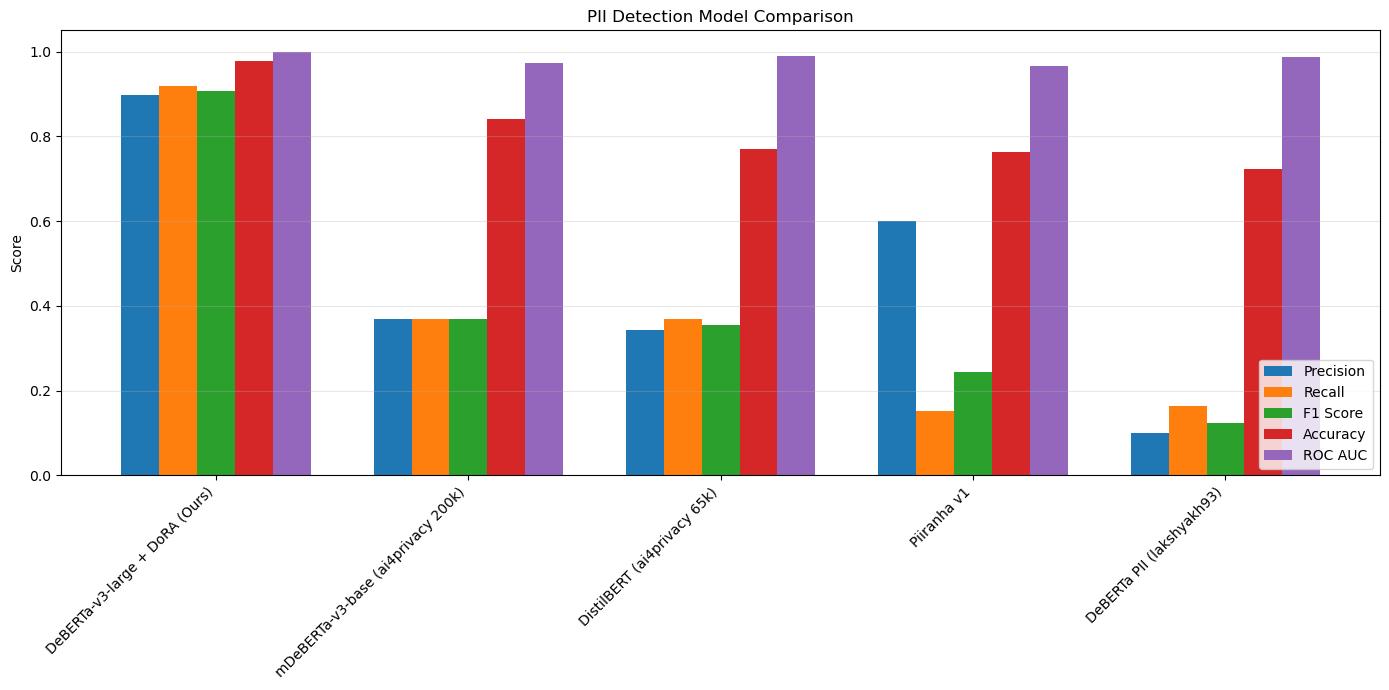

✓ Chart saved to pii_model_comparison_chart.png


In [24]:
try:
    import matplotlib.pyplot as plt

    if successful:
        # Prepare data
        models = df["Model"].tolist()
        metrics_to_plot = ["Precision", "Recall", "F1 Score", "Accuracy", "ROC AUC"]

        x = np.arange(len(models))
        width = 0.15  # Width of each bar

        fig, ax = plt.subplots(figsize=(14, 7))

        # Create bars for each metric
        for i, metric in enumerate(metrics_to_plot):
            values = df[metric].tolist()
            offset = (i - len(metrics_to_plot) / 2 + 0.5) * width
            bars = ax.bar(x + offset, values, width, label=metric)

        # Formatting
        ax.set_ylabel("Score")
        ax.set_title("PII Detection Model Comparison")
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha="right")
        ax.legend(loc="lower right")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.savefig("pii_model_comparison_chart.png", dpi=150)
        plt.show()

        print("✓ Chart saved to pii_model_comparison_chart.png")

except ImportError:
    print("⚠ matplotlib not installed. Skipping visualization.")
    print("  Install with: pip install matplotlib")